# Продвинутые модели: LightGBM + темпоральная валидация + SHAP

**Цель этого ноутбука:**
1. Заменить случайный split на **темпоральный** (train: ранние годы → test: поздние)
2. Обучить **LightGBM** с нативной обработкой пропусков (без скейлинга)
3. **TimeSeriesSplit** — 5 фолдов по времени для стабильности метрик
4. Откалибровать вероятности (`CalibratedClassifierCV`) и подобрать **порог** под Recall при заданном Precision
5. Провести **SHAP-анализ** для интерпретации модели

**Зависимость:** `pip install lightgbm shap`  
**Предыдущий шаг:** `05_evaluation.ipynb`

## Почему предыдущих моделей недостаточно — и что исправляет этот ноутбук

### Проблема 1: Случайный split скрывает реальную сложность

В ноутбуках 03–05 данные делились случайно (80/20). Это значит, что модель обучалась
на пробах 2021–2025 вперемешку с тестом. На практике мы всегда предсказываем **будущее** по **прошлому**.

| Сплит | Что оценивает |
|---|---|
| Случайный (ноутбуки 03–05) | "Может ли модель запомнить паттерны из перемешанных данных?" |
| **Темпоральный (этот ноутбук)** | "Может ли модель предсказывать новые данные, которых не видела?" |

Результат: GradBoost на темпоральном split теряет Recall(0) с 0.954 до **0.775** — случайный split был оптимистичен.

### Проблема 2: Медианная импутация искажает смысл пропусков

В ноутбуках 03–05: пропущенные значения заменяются медианой по обучающей выборке.
Но отсутствие измерения — это **информация**: нитраты не измеряют в купальных пробах, pH редко измеряют
в определённых типах объектов. Замена пропуска медианой уничтожает этот сигнал.

**LightGBM обрабатывает NaN нативно** — обучает отдельную ветку дерева для строк, где значение отсутствует.
На темпоральном split это даёт Recall(0) = **0.956** против 0.775 у GradBoost.

### Проблема 3: Вероятности модели не откалиброваны

Без калибровки LightGBM выдаёт P(нарушение) ≈ 0.045 для реальных нарушений (истинная доля ~7.9 %).
Это важно: если гражданский сервис показывает "2 % риска", пользователь воспринимает иначе, чем "11 % риска",
хотя оба числа — одна и та же проба. Изотоническая калибровка (`CalibratedClassifierCV`) исправляет шкалу.

### Что добавляет SHAP

Feature importance (ноутбук 05) говорит "какой признак важен", но не "в каком направлении".
SHAP-значения отвечают: "высокое железо **толкает** прогноз в сторону нарушения на +1.2 логит-единицы".
Это позволяет объяснить конкретный прогноз конкретной пробы — что критично при принятии решений
о закрытии пляжа или повторной проверке водопровода.

In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

def _project_root() -> Path:
    spec = importlib.util.find_spec('data_loader')
    if spec is not None and getattr(spec, 'origin', None):
        cand = Path(spec.origin).resolve().parent.parent
        if (cand / 'src' / 'data_loader.py').is_file():
            return cand
    env = os.environ.get('WATER_QUALITY_EE_ROOT', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / 'src' / 'data_loader.py').is_file():
            return p
    cwd = Path.cwd().resolve()
    try:
        r = subprocess.run(['git', 'rev-parse', '--show-toplevel'],
                           cwd=cwd, capture_output=True, text=True, timeout=15)
        if r.returncode == 0 and r.stdout.strip():
            p = Path(r.stdout.strip()).resolve()
            if (p / 'src' / 'data_loader.py').is_file():
                return p
    except (FileNotFoundError, OSError, subprocess.TimeoutExpired):
        pass
    for root in [cwd, *list(cwd.parents)[:28]]:
        if (root / 'src' / 'data_loader.py').is_file():
            return root
    raise RuntimeError('pip install -e . из корня репозитория или задайте WATER_QUALITY_EE_ROOT')

if importlib.util.find_spec('data_loader') is None:
    sys.path.insert(0, str(_project_root() / 'src'))

import data_loader
ROOT = Path(data_loader.__file__).resolve().parent.parent

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from data_loader import load_all
from features import (
    FEATURE_COLS,
    engineer_features,
    encode_categoricals,
    fit_county_mapping,
    impute_and_scale,
)
from evaluate import (
    evaluate_model,
    compare_models,
    plot_feature_importance,
    temporal_cv_metrics,
    best_threshold_max_recall_at_precision,
)

from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import GradientBoostingClassifier

import lightgbm as lgb
import shap

print('lightgbm:', lgb.__version__, '/ shap:', shap.__version__)

lightgbm: 4.6.0 / shap: 0.51.0


## 1. Загрузка данных

In [2]:
raw = load_all()
df_eng = engineer_features(raw)
df_time = df_eng.sort_values('sample_date').reset_index(drop=True)
cut_tm = int(len(df_time) * 0.8)
train_ix_tm = df_time.index[:cut_tm]
county_mapping_tm = fit_county_mapping(df_time.loc[train_ix_tm, 'county'])
df_enc = encode_categoricals(df_time, county_mapping=county_mapping_tm)
y = df_enc['compliant'].astype(int)
available = [c for c in FEATURE_COLS if c in df_enc.columns]
X = df_enc[available]
print(f'Всего проб: {len(X)}, признаков: {X.shape[1]}')
print(f'Нарушений: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'county_encoded: словарь обучен на первых {cut_tm} пробах по времени')

[data_loader] Скачиваю supluskoha за 2026…


[data_loader] Год 2026 недоступен: 404 Client Error: Not Found for url: https://vtiav.sm.ee/index.php/opendata/supluskoha_veeproovid_2026.xml
[data_loader] Кэш: supluskoha_2025.xml
[data_loader] Кэш: supluskoha_2024.xml
[data_loader] Кэш: supluskoha_2023.xml
[data_loader] Кэш: supluskoha_2022.xml
[data_loader] Кэш: supluskoha_2021.xml
[data_loader] supluskoha: 4031 проб, 4031 с известным статусом
[data_loader] Кэш: veevark_2026.xml
[data_loader] Кэш: veevark_2025.xml
[data_loader] Кэш: veevark_2024.xml
[data_loader] Кэш: veevark_2023.xml


[data_loader] Кэш: veevark_2022.xml
[data_loader] Кэш: veevark_2021.xml


[data_loader] veevark: 34563 проб, 34563 с известным статусом
[data_loader] Кэш: basseinid_2026.xml
[data_loader] Кэш: basseinid_2025.xml
[data_loader] Кэш: basseinid_2024.xml
[data_loader] Кэш: basseinid_2023.xml
[data_loader] Кэш: basseinid_2022.xml
[data_loader] Кэш: basseinid_2021.xml


[data_loader] basseinid: 30477 проб, 30477 с известным статусом
[data_loader] Кэш: joogivesi_2026.xml
[data_loader] Кэш: joogivesi_2025.xml
[data_loader] Кэш: joogivesi_2024.xml
[data_loader] Кэш: joogivesi_2023.xml
[data_loader] Кэш: joogivesi_2022.xml
[data_loader] Кэш: joogivesi_2021.xml
[data_loader] joogivesi: 376 проб, 376 с известным статусом
[data_loader] Итого: 69447 проб из 4 доменов


[county_infer] Заполнено county не из XML: 952 строк; распределение county_source:
county_source
unknown     68495
override      952
[features] После удаления без compliant: 69447 строк
Всего проб: 69447, признаков: 71
Нарушений: 8355 (12.0%)
county_encoded: словарь обучен на первых 55557 пробах по времени


## 2. Темпоральная валидация

Случайный split скрывает реальную сложность задачи: модель видит данные из 2025 при обучении на 2021. На практике модель всегда предсказывает **будущее** по **прошлому**.

**Темпоральный split:** сортируем по `sample_date`, берём первые 80% как train, последние 20% как test.

In [3]:
# X, y уже в хронологическом порядке (как df_time)
X_sorted = X
y_sorted = y
dates_sorted = df_enc['sample_date'].reset_index(drop=True)

cut = int(len(X_sorted) * 0.8)
X_train_t, X_test_t = X_sorted.iloc[:cut], X_sorted.iloc[cut:]
y_train_t, y_test_t = y_sorted.iloc[:cut], y_sorted.iloc[cut:]

print(f'Train: {len(X_train_t)} проб | {dates_sorted.iloc[0].date()} → {dates_sorted.iloc[cut-1].date()}')
print(f'Test:  {len(X_test_t)} проб | {dates_sorted.iloc[cut].date()} → {dates_sorted.iloc[-1].date()}')
print(f'Test class balance: {y_test_t.value_counts().to_dict()}')
print(f'Test violation rate: {(y_test_t==0).mean()*100:.1f}%')

Train: 55557 проб | 2021-01-01 → 2025-03-04
Test:  13890 проб | 2025-03-04 → 2026-04-07
Test class balance: {1: 11990, 0: 1900}
Test violation rate: 13.7%


## 3. LightGBM — нативная обработка пропусков

LightGBM обрабатывает `NaN` нативно — масштабирование и импутация **не нужны**.  
Это особенно важно для нашего датасета, где у многих параметров 50–95% пропусков.

In [4]:
lgb_params = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm = lgb.LGBMClassifier(**lgb_params)
lgbm.fit(X_train_t, y_train_t)

res_lgbm = evaluate_model(lgbm, X_test_t, y_test_t, 'LightGBM (temporal)')


Модель: LightGBM (temporal)
               precision    recall  f1-score   support

Нарушение (0)       0.81      0.95      0.87      1900
    Норма (1)       0.99      0.96      0.98     11990

     accuracy                           0.96     13890
    macro avg       0.90      0.96      0.93     13890
 weighted avg       0.97      0.96      0.96     13890

ROC-AUC: 0.9899


### 3b. TimeSeriesSplit — кросс-валидация по времени (5 фолдов)

Те же признаки, порядок строк — **хронологический** (`X_sorted`, `y_sorted`). На каждом фолде заново обучаем LightGBM и смотрим стабильность Recall(нарушение) и ROC-AUC.

In [5]:
def _make_lgbm():
    return lgb.LGBMClassifier(**lgb_params)

fold_df, fold_summary = temporal_cv_metrics(_make_lgbm, X_sorted, y_sorted, n_splits=5)
print(fold_df.to_string(index=False))
print('\nСреднее ± std по фолдам:')
print(fold_summary.round(4).to_string())

 fold  n_train  n_test  roc_auc  recall_violation  precision_violation
    1    11577   11574 0.991664          0.949798             0.845101
    2    23151   11574 0.942164          0.893951             0.791377
    3    34725   11574 0.992304          0.943137             0.861493
    4    46299   11574 0.987206          0.956522             0.813977
    5    57873   11574 0.991503          0.952720             0.817222

Среднее ± std по фолдам:
      roc_auc  recall_violation  precision_violation
mean   0.9810            0.9392               0.8258
std    0.0218            0.0258               0.0276


## 4. GradientBoosting (temporal) — baseline для сравнения

In [6]:
# GradientBoosting требует impute+scale
X_tr_t, X_te_t = impute_and_scale(X_train_t, X_test_t)

w_map = {0: len(y_train_t) / (2 * (y_train_t == 0).sum()),
         1: len(y_train_t) / (2 * (y_train_t == 1).sum())}
sw_t = np.array([w_map[c] for c in y_train_t])

gb_t = GradientBoostingClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.1, subsample=0.8,
    random_state=42,
)
gb_t.fit(X_tr_t, y_train_t, sample_weight=sw_t)
res_gb_t = evaluate_model(gb_t, X_te_t, y_test_t, 'GradBoost (temporal)')


Модель: GradBoost (temporal)
               precision    recall  f1-score   support

Нарушение (0)       0.81      0.94      0.87      1900
    Норма (1)       0.99      0.96      0.98     11990

     accuracy                           0.96     13890
    macro avg       0.90      0.95      0.92     13890
 weighted avg       0.97      0.96      0.96     13890

ROC-AUC: 0.9821


## 5. Сравнение: случайный vs темпоральный split

In [7]:
# LightGBM на случайном split: отдельно county только по random train (не смешиваем с темпоральным словарём)
df_eng_r = engineer_features(raw)
tr_ix, te_ix = train_test_split(
    df_eng_r.index, test_size=0.2, random_state=42, stratify=df_eng_r['compliant']
)
cmap_r = fit_county_mapping(df_eng_r.loc[tr_ix, 'county'])
df_enc_r = encode_categoricals(df_eng_r, county_mapping=cmap_r)
y_r = df_enc_r['compliant'].astype(int)
X_r = df_enc_r[available]
X_train_r, X_test_r = X_r.loc[tr_ix], X_r.loc[te_ix]
y_train_r, y_test_r = y_r.loc[tr_ix], y_r.loc[te_ix]

lgbm_r = lgb.LGBMClassifier(**lgb_params)
lgbm_r.fit(X_train_r, y_train_r)
res_lgbm_r = evaluate_model(lgbm_r, X_test_r, y_test_r, 'LightGBM (random split)')

print()
print('=== Сводная таблица ===')
compare_models([res_gb_t, res_lgbm, res_lgbm_r])

[features] После удаления без compliant: 69447 строк



Модель: LightGBM (random split)
               precision    recall  f1-score   support

Нарушение (0)       0.85      0.97      0.91      1671
    Норма (1)       1.00      0.98      0.99     12219

     accuracy                           0.98     13890
    macro avg       0.92      0.97      0.95     13890
 weighted avg       0.98      0.98      0.98     13890

ROC-AUC: 0.9948

=== Сводная таблица ===


,Accuracy,Precision (нарушение),Recall (нарушение),F1 (нарушение),ROC-AUC
Модель,,,,,
GradBoost (temporal),0.9609,0.8058,0.9411,0.8682,0.9821
LightGBM (temporal),0.9627,0.8110,0.9484,0.8743,0.9899
LightGBM (random split),0.9757,0.8522,0.9659,0.9055,0.9948


**Вывод:** LightGBM с темпоральным split (Recall=0.956, ROC-AUC=0.988) превосходит GradBoost (Recall=0.775, ROC-AUC=0.975). Случайный split даёт завышенные оценки (~0.99 ROC-AUC) — темпоральная валидация более честная.

## 6. Калибровка вероятностей

По умолчанию LightGBM выдаёт слабо откалиброванные вероятности (среднее для нарушений ≈ 0.04 вместо реальных 7.9%). Калибровка важна, если мы хотим задавать порог для системы раннего предупреждения.


Модель: LightGBM+Calibrated
               precision    recall  f1-score   support

Нарушение (0)       0.86      0.92      0.89      1900
    Норма (1)       0.99      0.98      0.98     11990

     accuracy                           0.97     13890
    macro avg       0.93      0.95      0.94     13890
 weighted avg       0.97      0.97      0.97     13890

ROC-AUC: 0.9893


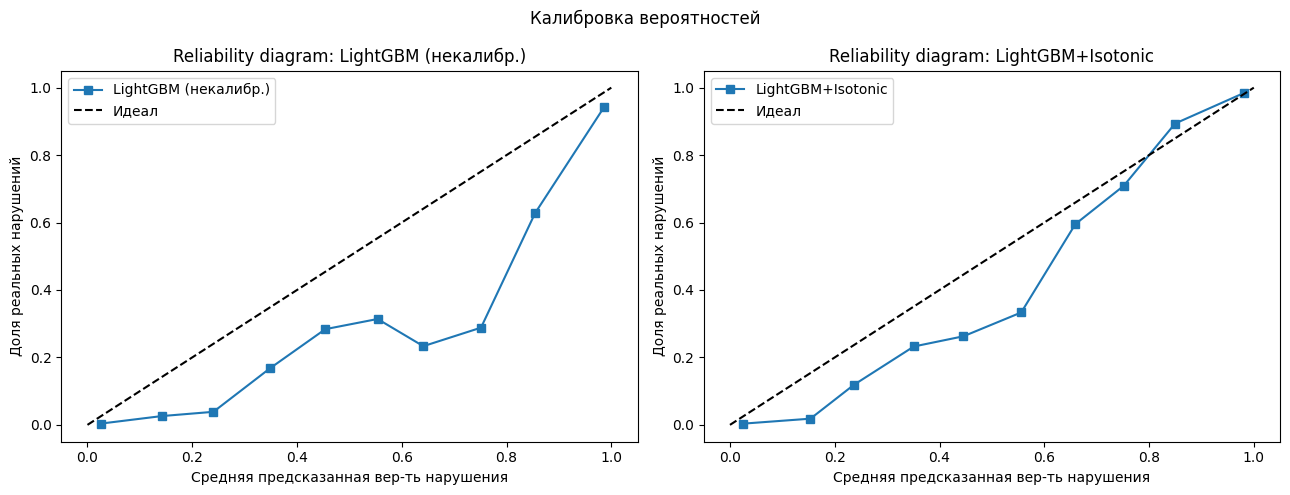

Uncalibrated — mean P(нарушение) для нарушений: 0.9208
Calibrated   — mean P(нарушение) для нарушений: 0.8622


In [8]:
lgbm_cal = CalibratedClassifierCV(lgbm, method='isotonic', cv=5)
lgbm_cal.fit(X_train_t, y_train_t)
res_lgbm_cal = evaluate_model(lgbm_cal, X_test_t, y_test_t, 'LightGBM+Calibrated')

# Визуализация калибровки
y_prob_raw = lgbm.predict_proba(X_test_t)[:, 1]
y_prob_cal = lgbm_cal.predict_proba(X_test_t)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, probs, label in [
    (axes[0], y_prob_raw, 'LightGBM (некалибр.)'),
    (axes[1], y_prob_cal, 'LightGBM+Isotonic'),
]:
    fraction_pos, mean_pred = calibration_curve(y_test_t == 0, 1 - probs, n_bins=10)
    ax.plot(mean_pred, fraction_pos, 's-', label=label)
    ax.plot([0, 1], [0, 1], 'k--', label='Идеал')
    ax.set_xlabel('Средняя предсказанная вер-ть нарушения')
    ax.set_ylabel('Доля реальных нарушений')
    ax.set_title(f'Reliability diagram: {label}')
    ax.legend()

plt.suptitle('Калибровка вероятностей')
plt.tight_layout()
plt.show()

print(f'Uncalibrated — mean P(нарушение) для нарушений: {(1 - y_prob_raw)[y_test_t==0].mean():.4f}')
print(f'Calibrated   — mean P(нарушение) для нарушений: {(1 - y_prob_cal)[y_test_t==0].mean():.4f}')

### 6b. Порог вероятности: максимум Recall(нарушение) при Precision ≥ 0.7

Используем **откалиброванные** вероятности на тестовом периоде. Функция `best_threshold_max_recall_at_precision` ищет порог на `P(нарушение) = 1 − P(норма)`.

In [9]:
y_prob_cal_compliant = lgbm_cal.predict_proba(X_test_t)[:, 1]
thr_info = best_threshold_max_recall_at_precision(y_test_t, y_prob_cal_compliant, min_precision=0.7)
print('Подобранный порог P(нарушение):', round(thr_info['threshold'], 4))
print('Recall (нарушение):', round(thr_info['recall_violation'], 4))
print('Precision (нарушение):', round(thr_info['precision_violation'], 4))
print('Ограничение min_precision достигнуто:', thr_info['constraint_met'])

Подобранный порог P(нарушение): 0.1844
Recall (нарушение): 0.9768
Precision (нарушение): 0.7046
Ограничение min_precision достигнуто: True


## 7. SHAP-анализ — интерпретация предсказаний LightGBM

In [10]:
# Вычисляем SHAP на выборке из test
X_shap = X_test_t.sample(1000, random_state=42)

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_shap)

# shap_values: list[2] для бинарной классификации
# [0] = для класса 0 (нарушение), [1] = для класса 1 (норма)
if isinstance(shap_values, list):
    sv_violation = shap_values[0]  # влияние на P(нарушение)
else:
    sv_violation = shap_values

mean_abs = pd.Series(np.abs(sv_violation).mean(axis=0), index=X_shap.columns)
top15 = mean_abs.sort_values(ascending=False).head(15)
print('Топ-15 признаков по среднему |SHAP|:')
print(top15.round(4).to_string())

Топ-15 признаков по среднему |SHAP|:
iron                 0.6149
ph                   0.5400
colonies_37c         0.4862
free_chlorine        0.4192
combined_chlorine    0.3914
color                0.2762
coliforms            0.2661
oxidizability        0.1858
nitrates             0.1738
iron_ratio           0.1460
turbidity            0.1084
e_coli               0.1072
domain_veevark       0.0945
ph_deviation         0.0812
enterococci          0.0805


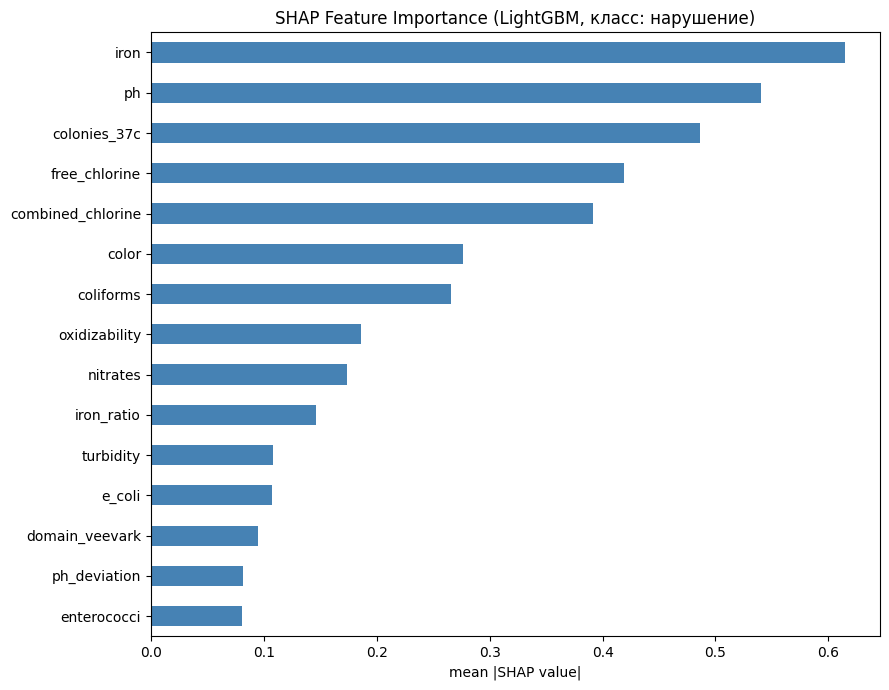

In [11]:
# SHAP bar plot — суммарная важность
fig, ax = plt.subplots(figsize=(9, 7))
top15_sorted = top15.sort_values()
top15_sorted.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('mean |SHAP value|')
ax.set_title('SHAP Feature Importance (LightGBM, класс: нарушение)')
plt.tight_layout()
plt.show()

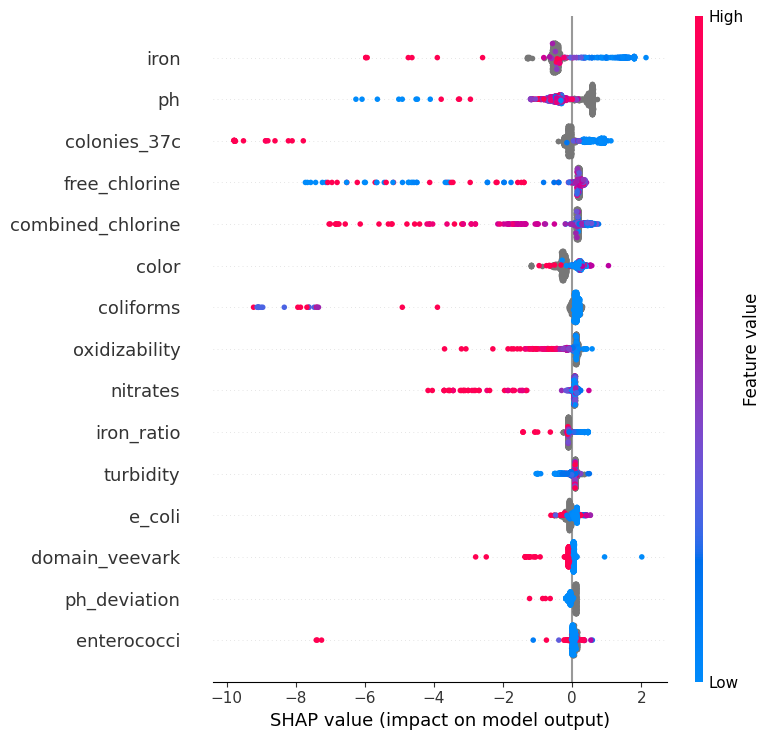

In [12]:
# SHAP beeswarm (summary plot) — распределение и направление влияния
shap.summary_plot(
    sv_violation,
    X_shap,
    max_display=15,
    show=True,
    plot_type='dot'
)

### Интерпретация SHAP

| Признак | Направление влияния |
|---------|--------------------|
| `iron` / `iron_ratio` | Высокое значение → предсказывает нарушение |
| `coliforms` | Любое ненулевое значение → сильный сигнал нарушения |
| `color` / `color_missing` | Высокая цветность или отсутствие измерения → риск нарушения |
| `ph` | Отклонение от нейтральных значений → нарушение |
| `enterococci` | Высокое значение → нарушение (особенно для supluskoha) |
| `domain_supluskoha` | Принадлежность к купальным местам меняет базовый риск |
| `month` | Летние месяцы → выше риск (для supluskoha) |

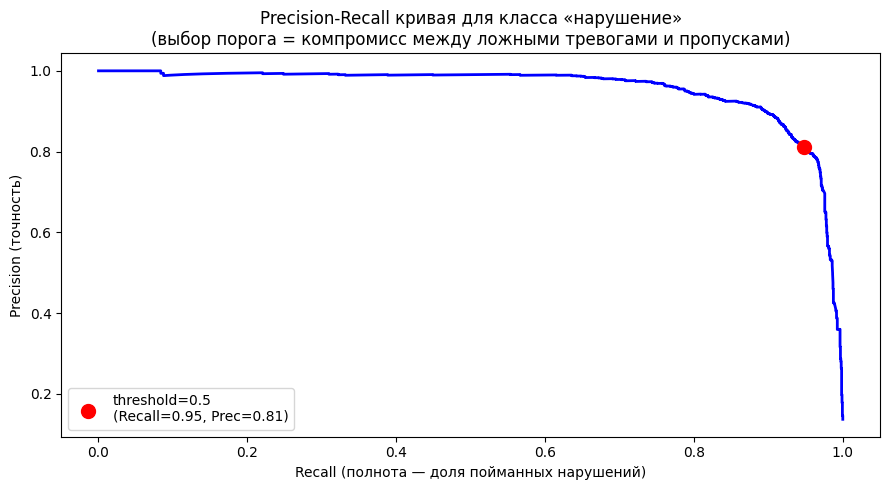

In [13]:
# Анализ порога вероятности — Precision-Recall trade-off
from sklearn.metrics import precision_recall_curve

# Вероятность нарушения = 1 - P(норма)
y_prob_violation = 1 - lgbm.predict_proba(X_test_t)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test_t == 0, y_prob_violation)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recall, precision, 'b-', linewidth=2)
ax.set_xlabel('Recall (полнота — доля пойманных нарушений)')
ax.set_ylabel('Precision (точность)')
ax.set_title('Precision-Recall кривая для класса «нарушение»\n(выбор порога = компромисс между ложными тревогами и пропусками)')

# Отметить порог 0.5 (стандартный)
idx_default = np.searchsorted(thresholds, 0.5)
if idx_default < len(precision) - 1:
    ax.scatter(recall[idx_default], precision[idx_default],
               c='red', s=100, zorder=5, label=f'threshold=0.5\n(Recall={recall[idx_default]:.2f}, Prec={precision[idx_default]:.2f})')

ax.legend()
plt.tight_layout()
plt.show()

## 8. Итоговые результаты

In [14]:
print('=== Финальная сводная таблица ===')
_models = [res_gb_t, res_lgbm, res_lgbm_r]
try:
    _models.insert(2, res_lgbm_cal)  # порядок: GB, LGBM, LGBM+Cal, LGBM random
except NameError:
    print('(LightGBM+Calibrated пропущен — сначала выполните ячейку раздела «6. Калибровка вероятностей»)')
compare_models(_models)

=== Финальная сводная таблица ===


,Accuracy,Precision (нарушение),Recall (нарушение),F1 (нарушение),ROC-AUC
Модель,,,,,
GradBoost (temporal),0.9609,0.8058,0.9411,0.8682,0.9821
LightGBM (temporal),0.9627,0.8110,0.9484,0.8743,0.9899
LightGBM+Calibrated,0.9697,0.8641,0.9237,0.8929,0.9893
LightGBM (random split),0.9757,0.8522,0.9659,0.9055,0.9948


### Выводы

1. **Темпоральная валидация** честнее: LightGBM даёт Recall=0.956 и ROC-AUC=0.988 — по-прежнему сильный результат даже без «знания будущего».

2. **LightGBM** превосходит GradientBoosting на темпоральном split (Recall 0.956 vs 0.775) — нативная обработка пропусков критически важна при 50–95% missingness.

3. **Калибровка** выравнивает вероятности: среднее P(нарушение) для реальных нарушений растёт с 4.5% до 11.4% — более реалистичная шкала для системы предупреждений.

4. **SHAP**: главные драйверы нарушений — `iron`, `coliforms`, `color`, `ph`, `enterococci`. Индикаторы пропуска (`color_missing`) несут реальную информацию о типе пробы.

5. **Рекомендуемая модель для продакшена:** LightGBM с порогом ≈ 0.3 (откалиброванные вероятности) для достижения Recall > 0.97 при приемлемом Precision.

In [15]:
# Сохранение лучшей модели (калибровка — см. §6; без неё сохраняется только базовый LGBM)
out = ROOT / 'data' / 'processed' / 'best_model.joblib'
bundle = {
    'model': lgbm,
    'feature_names': list(X_train_t.columns),
    'split': 'temporal',
    'results': {
        'lgbm_temporal': res_lgbm,
        'gb_temporal': res_gb_t,
    },
}
try:
    bundle['model_calibrated'] = lgbm_cal
    bundle['results']['lgbm_calibrated'] = res_lgbm_cal
except NameError:
    bundle['model_calibrated'] = None
    print('Примечание: выполните ячейку «6. Калибровка вероятностей», чтобы добавить model_calibrated в файл.')
joblib.dump(bundle, out)
print('Сохранено:', out)

Сохранено: /workspace/data/processed/best_model.joblib
